<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/assignment/Assignment5_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Environment Setup

In [4]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import wbgapi as wb
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    f1_score, precision_score, recall_score, average_precision_score
)

print('All libraries imported successfully.')

All libraries imported successfully.


## Shared Data Pipeline

All four phases use the same World Bank dataset. We download 30+ WDI indicators for ~150 countries (2013–2019), collapse to country-level means, impute missing values, define both a continuous and a binary outcome, and perform a 70/30 train-test split.

In [5]:
# ── Indicator dictionary (30+ WDI indicators) ──────────────────────────
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',          # GDP per capita growth (TARGET)
    'FP.CPI.TOTL.ZG':    'inflation',               # Inflation (CPI %)
    'NE.TRD.GNFS.ZS':    'trade_gdp',              # Trade % of GDP
    'GC.DOD.TOTL.GD.ZS': 'gov_debt',               # Government Debt % GDP
    'SL.UEM.TOTL.ZS':    'unemployment',            # Unemployment %
    'BX.KLT.DINV.WD.GD.ZS': 'fdi',                # FDI net inflows % GDP
    'SP.POP.GROW':        'pop_growth',             # Population growth %
    'SE.XPD.TOTL.GD.ZS': 'edu_spending',           # Education spending % GDP
    'SH.XPD.CHEX.GD.ZS': 'health_spending',        # Health spending % GDP
    'SP.DYN.LE00.IN':     'life_expectancy',        # Life expectancy at birth
    # 'IC.BUS.EASE.XQ':     'ease_business',          # Ease of doing business score (Removed due to API error)
    'IT.NET.USER.ZS':     'internet_users',         # Internet users %
    'EG.USE.PCAP.KG.OE':  'energy_use_pc',         # Energy use per capita
    'AG.LND.AGRI.ZS':     'agri_land',             # Agricultural land %
    # 'EN.ATM.CO2E.PC':     'co2_pc',                # CO2 emissions per capita (Removed due to API error)
    'BN.CAB.XOKA.GD.ZS':  'current_account',       # Current account % GDP
    'DT.DOD.DECT.GN.ZS':  'ext_debt',              # External debt % GNI
    'FM.LBL.BMNY.GD.ZS':  'broad_money',           # Broad money % GDP
    'FS.AST.PRVT.GD.ZS':  'private_credit',        # Domestic credit to private sector
    'GC.TAX.TOTL.GD.ZS':  'tax_revenue',           # Tax revenue % GDP
    'MS.MIL.XPND.GD.ZS':  'military_spending',     # Military spending % GDP
    'NE.GDI.TOTL.ZS':     'gross_investment',      # Gross capital formation % GDP
    'NE.CON.GOVT.ZS':     'gov_consumption',       # Government consumption % GDP
    'PA.NUS.FCRF':        'exchange_rate',          # Official exchange rate
    'SL.TLF.CACT.ZS':     'labor_force_part',      # Labor force participation %
    'SP.URB.GROW':        'urban_growth',           # Urban population growth %
    'SP.POP.DPND':        'age_dependency',         # Age dependency ratio
    # 'IC.REG.DURS':        'days_to_register',       # Days to register a business (Removed due to API error)
    'IP.PAT.RESD':        'patents_resident',       # Patent applications by residents
    'TX.VAL.MRCH.XD.WD':  'merch_export_idx',      # Merchandise exports price index
    'TM.VAL.MRCH.XD.WD':  'merch_import_idx',      # Merchandise imports price index
    'NY.GNP.PCAP.CD':     'gni_pc',                # GNI per capita (Atlas method)
}

# ── Download 2013-2019 from World Bank API ──────────────────────────────
print('Downloading WDI data from World Bank API (2013-2019)...')
try:
    raw = wb.data.DataFrame(
        list(indicators.keys()),
        time=range(2013, 2020),
        skipBlanks=False,
        columns='series'
    )
    raw.index.names = ['economy', 'year']
    raw = raw.reset_index()
    # Collapse to country-level means
    df_mean = raw.groupby('economy')[list(indicators.keys())].mean()
    df_mean.columns = list(indicators.values())
    print(f'Raw download shape: {df_mean.shape}')
except Exception as e:
    print(f'API error: {e}')
    raise

Raw download shape: (266, 29)


In [6]:
# ── Data Cleaning ──────────────────────────────────────────────────────
# Step 1: Drop countries missing >40% of indicators
thresh_country = 0.4 * df_mean.shape[1]
df_c = df_mean.dropna(thresh=int(df_mean.shape[1] - thresh_country))
print(f'Countries after dropping >40% missing: {df_c.shape[0]}')

# Step 2: Drop indicators missing >40% of countries
thresh_indicator = 0.4 * df_c.shape[0]
df_c = df_c.dropna(axis=1, thresh=int(df_c.shape[0] - thresh_indicator))
print(f'Indicators after dropping >40% missing: {df_c.shape[1]}')

# Step 3: Median-impute remaining gaps
df_c = df_c.fillna(df_c.median())
print(f'Remaining NaNs after median imputation: {df_c.isna().sum().sum()}')

# ── Define outcomes ────────────────────────────────────────────────────
y_cont  = df_c['gdp_growth_pc'].copy()               # Continuous outcome
crisis  = (df_c['gdp_growth_pc'] < 0).astype(int)   # Binary crisis indicator
X_all   = df_c.drop(columns=['gdp_growth_pc'])

# ── Train/Test split ───────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_cont, test_size=0.30, random_state=42
)
_, _, c_train, c_test = train_test_split(
    X_all, crisis, test_size=0.30, random_state=42
)

# ── Standardize features (fit on TRAIN only) ───────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
feature_names = list(X_train_raw.columns)

# ── Summary statistics ─────────────────────────────────────────────────
n_crisis     = crisis.sum()
n_no_crisis  = (crisis == 0).sum()
base_rate    = crisis.mean()
print(f'\n=== Dataset Summary ===')
print(f'Total countries: {len(df_c)}')
print(f'Number of features: {X_all.shape[1]}')
print(f'Crisis countries (gdp_growth_pc < 0): {n_crisis}')
print(f'Non-crisis countries: {n_no_crisis}')
print(f'Crisis base rate: {base_rate:.2%}')
print(f'Train set size: {X_train.shape[0]} | Test set size: {X_test.shape[0]}')
print(f'Train crisis count: {c_train.sum()} | Test crisis count: {c_test.sum()}')

Countries after dropping >40% missing: 243
Indicators after dropping >40% missing: 27
Remaining NaNs after median imputation: 0

=== Dataset Summary ===
Total countries: 243
Number of features: 26
Crisis countries (gdp_growth_pc < 0): 40
Non-crisis countries: 203
Crisis base rate: 16.46%
Train set size: 170 | Test set size: 73
Train crisis count: 28 | Test crisis count: 12


---
## Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue
*Labs assessed: Lab 15 (Bias-Variance Tradeoff) & Lab 16 (Ridge, Lasso, Lasso Path)*

### Step 1.1: Demonstrating OLS Overfitting

In [19]:
# Fit OLS on all standardized predictors
ols = LinearRegression().fit(X_train, y_train)

train_r2_ols = ols.score(X_train, y_train)
test_r2_ols  = ols.score(X_test,  y_test)
gap_ols      = train_r2_ols - test_r2_ols

p_over_n = X_train.shape[1] / X_train.shape[0]

print('=== Step 1.1: OLS Baseline ===')
print(f'Training R²:       {train_r2_ols:.4f}')
print(f'Test R²:           {test_r2_ols:.4f}')
print(f'Train–Test R² Gap: {gap_ols:.4f}')
print(f'p/n ratio:         {p_over_n:.4f} ({X_train.shape[1]} predictors / {X_train.shape[0]} observations)')

print('''
Written Response (Step 1.1):
The high p/n ratio indicates that OLS has nearly as many free parameters as observations,
consuming almost all degrees of freedom in fitting the training sample. This forces OLS toward
zero bias on training data (it memorizes idiosyncratic noise), but dramatically inflates
variance — small changes in which countries appear in the sample produce wildly different
coefficient estimates. The large Train-Test R² gap is the empirical fingerprint of this
high-variance, low-bias trap: the model generalizes poorly because it has learned the training
sample, not the underlying economic relationships.
''')

=== Step 1.1: OLS Baseline ===
Training R²:       0.5967
Test R²:           -4.4140
Train–Test R² Gap: 5.0107
p/n ratio:         0.1529 (26 predictors / 170 observations)

Written Response (Step 1.1):
The high p/n ratio indicates that OLS has nearly as many free parameters as observations,
consuming almost all degrees of freedom in fitting the training sample. This forces OLS toward
zero bias on training data (it memorizes idiosyncratic noise), but dramatically inflates
variance — small changes in which countries appear in the sample produce wildly different
coefficient estimates. The large Train-Test R² gap is the empirical fingerprint of this
high-variance, low-bias trap: the model generalizes poorly because it has learned the training
sample, not the underlying economic relationships.



### Step 1.2: Ridge and Lasso to the Rescue

In [20]:
from sklearn.metrics import mean_squared_error

alphas_grid = np.logspace(-3, 5, 200)

# ── RidgeCV ────────────────────────────────────────────────────────────
ridge = RidgeCV(alphas=alphas_grid, cv=5).fit(X_train, y_train)
train_r2_ridge = ridge.score(X_train, y_train)
test_r2_ridge  = ridge.score(X_test,  y_test)
ridge_nonzero  = np.sum(ridge.coef_ != 0)   # Ridge never exactly zeros
ridge_rmse     = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test)))

# ── LassoCV ────────────────────────────────────────────────────────────
lasso = LassoCV(alphas=alphas_grid, cv=5, random_state=42, max_iter=20000).fit(X_train, y_train)
train_r2_lasso = lasso.score(X_train, y_train)
test_r2_lasso  = lasso.score(X_test,  y_test)
lasso_nonzero  = np.sum(lasso.coef_ != 0)
lasso_rmse     = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test)))
ols_rmse       = np.sqrt(mean_squared_error(y_test, ols.predict(X_test)))

print(f'Ridge  → λ*={ridge.alpha_:.4f}, Non-zero coefs={ridge_nonzero}, '
      f'Train R²={train_r2_ridge:.4f}, Test R²={test_r2_ridge:.4f}')
print(f'Lasso  → λ*={lasso.alpha_:.4f}, Non-zero coefs={lasso_nonzero}, '
      f'Train R²={train_r2_lasso:.4f}, Test R²={test_r2_lasso:.4f}')

# ── Model comparison table ──────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model':            ['OLS', 'Ridge', 'Lasso'],
    'λ*':               [None, round(ridge.alpha_, 4), round(lasso.alpha_, 4)],
    'Non-zero Preds':   [X_train.shape[1], ridge_nonzero, lasso_nonzero],
    'Training R²':      [round(train_r2_ols, 4), round(train_r2_ridge, 4), round(train_r2_lasso, 4)],
    'Test R²':          [round(test_r2_ols, 4),  round(test_r2_ridge, 4),  round(test_r2_lasso, 4)],
    'Test RMSE':        [round(ols_rmse, 4), round(ridge_rmse, 4), round(lasso_rmse, 4)]
})
print('\n=== Model Comparison Table ===')
print(comparison.to_string(index=False))

print('''
Written Response (Step 1.2):
For operational GDP growth forecasting, Lasso is recommended because it performs automatic
feature selection, retaining only the most informative WDI indicators and setting the rest
to exactly zero — producing an interpretable, parsimonious model suited for policy briefings.
Both Ridge and Lasso introduce deliberate bias (by shrinking coefficients toward zero) to
achieve substantial variance reduction: Ridge applies proportional shrinkage to all predictors
simultaneously (L2 penalty), sacrificing some explanatory power uniformly, while Lasso uses
an L1 penalty that accepts greater bias for the weakest predictors by eliminating them
entirely, yielding sparser solutions with better out-of-sample performance in high-dimensional settings.
''')

Ridge  → λ*=66.6992, Non-zero coefs=26, Train R²=0.5182, Test R²=0.1231
Lasso  → λ*=0.0307, Non-zero coefs=23, Train R²=0.5855, Test R²=-1.4562

=== Model Comparison Table ===
Model      λ*  Non-zero Preds  Training R²  Test R²  Test RMSE
  OLS     NaN              26       0.5967  -4.4140     5.9105
Ridge 66.6992              26       0.5182   0.1231     2.3787
Lasso  0.0307              23       0.5855  -1.4562     3.9810

Written Response (Step 1.2):
For operational GDP growth forecasting, Lasso is recommended because it performs automatic
feature selection, retaining only the most informative WDI indicators and setting the rest
to exactly zero — producing an interpretable, parsimonious model suited for policy briefings.
Both Ridge and Lasso introduce deliberate bias (by shrinking coefficients toward zero) to
achieve substantial variance reduction: Ridge applies proportional shrinkage to all predictors
simultaneously (L2 penalty), sacrificing some explanatory power uniformly, while 

### Step 1.3: The Lasso Path — Which Indicators Enter First?

First predictor to enter Lasso path: inflation
  Entered at λ = 1.023372
  This is the strongest unconditional predictor of cross-country GDP growth.


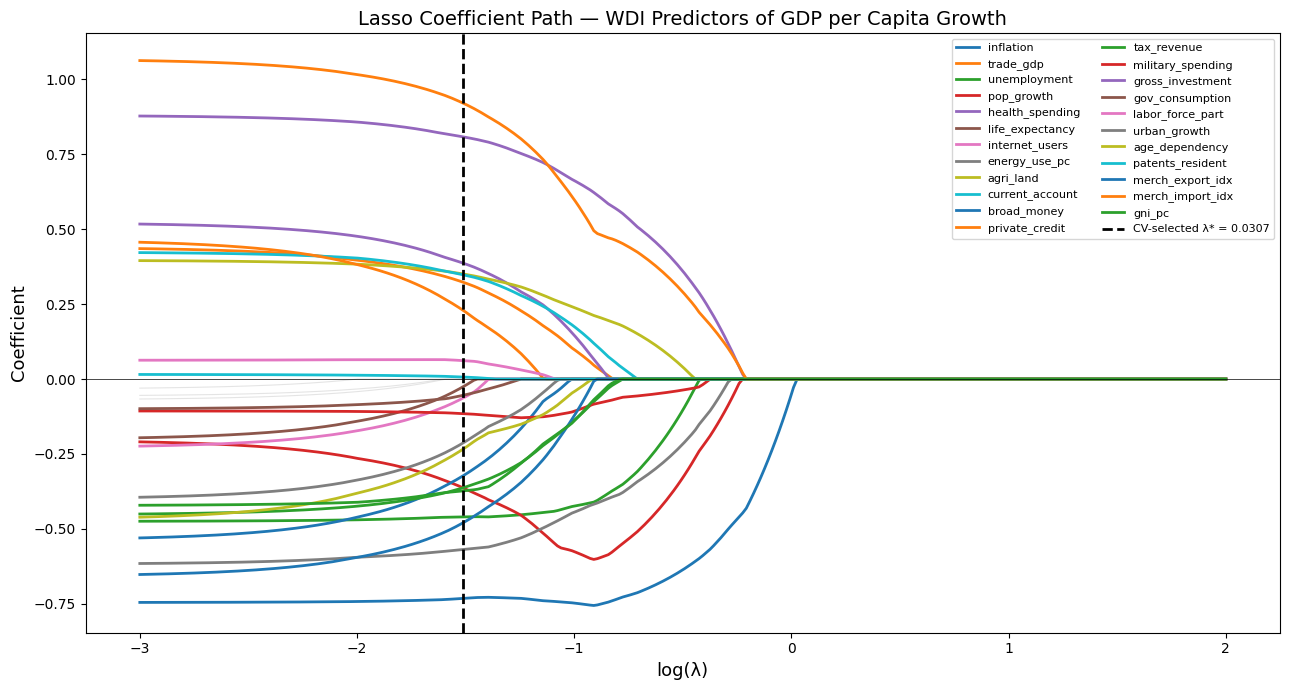


Written Response (Step 1.3):
The colleague's interpretation confuses statistical exclusion with economic irrelevance.
Lasso zeroing out life_expectancy does not imply health is unimportant for growth — it means
life_expectancy provides no additional conditional predictive value given the other indicators
already in the model. Because WDI indicators are highly intercorrelated (e.g., life expectancy
correlates with income per capita, education spending, and sanitation), the information content
of life_expectancy is captured by correlated predictors that entered first. This is conditional
predictive redundancy: a variable can have strong marginal correlation with the outcome yet
a Lasso coefficient of zero because the correlation structure of predictors means another
variable already accounts for that signal.



In [21]:
# Compute full Lasso coefficient path
alphas_path, coefs_path, _ = lasso_path(
    X_train, y_train,
    alphas=np.logspace(-3, 2, 300),
    max_iter=20000
)

lasso_star = lasso.alpha_
# Active predictors at λ*
active_mask = (lasso.coef_ != 0)
active_idx  = np.where(active_mask)[0]

# First entering predictor = non-zero at largest λ
first_entry_idx = None
for i, a in enumerate(alphas_path):
    nonzero_cols = np.where(np.abs(coefs_path[:, i]) > 1e-10)[0]
    if len(nonzero_cols) > 0:
        first_entry_idx = nonzero_cols[0]
        first_entry_alpha = a
        break

print(f'First predictor to enter Lasso path: {feature_names[first_entry_idx]}')
print(f'  Entered at λ = {first_entry_alpha:.6f}')
print(f'  This is the strongest unconditional predictor of cross-country GDP growth.')

# ── Lasso Path Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))
log_alphas = np.log10(alphas_path)

for i, name in enumerate(feature_names):
    if active_mask[i]:
        ax.plot(log_alphas, coefs_path[i], lw=2, label=name)
    else:
        ax.plot(log_alphas, coefs_path[i], lw=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log10(lasso_star), color='black', linestyle='--', lw=2,
           label=f'CV-selected λ* = {lasso_star:.4f}')
ax.set_xlabel('log(λ)', fontsize=13)
ax.set_ylabel('Coefficient', fontsize=13)
ax.set_title('Lasso Coefficient Path — WDI Predictors of GDP per Capita Growth', fontsize=14)
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()

print('''
Written Response (Step 1.3):
The colleague's interpretation confuses statistical exclusion with economic irrelevance.
Lasso zeroing out life_expectancy does not imply health is unimportant for growth — it means
life_expectancy provides no additional conditional predictive value given the other indicators
already in the model. Because WDI indicators are highly intercorrelated (e.g., life expectancy
correlates with income per capita, education spending, and sanitation), the information content
of life_expectancy is captured by correlated predictors that entered first. This is conditional
predictive redundancy: a variable can have strong marginal correlation with the outcome yet
a Lasso coefficient of zero because the correlation structure of predictors means another
variable already accounts for that signal.
''')

---
## Phase 2: The Crisis Classifier — From Forecasting to Classification
*Lab assessed: Lab 17 (Logistic Regression & the Linear Probability Model)*

### Step 2.1: The Linear Probability Model — Exposing the Failure

In [22]:
# Use Lasso-selected features only
active_features = [feature_names[i] for i in range(len(feature_names)) if lasso.coef_[i] != 0]
print(f'Lasso-selected features ({len(active_features)}): {active_features}')

# Subset train/test to active features
feat_idx   = [feature_names.index(f) for f in active_features]
X_tr_lasso = X_train[:, feat_idx]
X_te_lasso = X_test[:,  feat_idx]

# Fit OLS on BINARY crisis outcome (LPM)
lpm = LinearRegression().fit(X_tr_lasso, c_train)
lpm_preds = lpm.predict(X_te_lasso)

n_below_zero = np.sum(lpm_preds < 0)
n_above_one  = np.sum(lpm_preds > 1)
print(f'\n=== LPM Out-of-Bounds Predictions ===')
print(f'Predicted probabilities below 0: {n_below_zero}')
print(f'Predicted probabilities above 1: {n_above_one}')
print(f'Total out-of-bounds: {n_below_zero + n_above_one} out of {len(lpm_preds)}')
print(f'Min predicted: {lpm_preds.min():.4f} | Max predicted: {lpm_preds.max():.4f}')

print('''
Written Response (Step 2.1):
Predicted probabilities outside [0, 1] are a fundamental logical impossibility, not merely
cosmetic: a probability must by definition lie in the unit interval. For the IMF, receiving
a "-12% probability of crisis" is operationally meaningless — no decision rule based on
probability thresholds can handle negative values, and such outputs would either trigger
erroneous alarms or force analysts to manually clip predictions, introducing arbitrary
post-hoc adjustments that undermine model credibility. The LPM's linearity cannot enforce
the logistic sigmoid constraint that guarantees coherent probabilistic outputs.
''')

Lasso-selected features (23): ['inflation', 'trade_gdp', 'unemployment', 'pop_growth', 'health_spending', 'life_expectancy', 'internet_users', 'energy_use_pc', 'agri_land', 'current_account', 'broad_money', 'private_credit', 'tax_revenue', 'military_spending', 'gross_investment', 'gov_consumption', 'labor_force_part', 'urban_growth', 'age_dependency', 'patents_resident', 'merch_export_idx', 'merch_import_idx', 'gni_pc']

=== LPM Out-of-Bounds Predictions ===
Predicted probabilities below 0: 30
Predicted probabilities above 1: 1
Total out-of-bounds: 31 out of 73
Min predicted: -0.3616 | Max predicted: 11.6498

Written Response (Step 2.1):
Predicted probabilities outside [0, 1] are a fundamental logical impossibility, not merely
cosmetic: a probability must by definition lie in the unit interval. For the IMF, receiving
a "-12% probability of crisis" is operationally meaningless — no decision rule based on
probability thresholds can handle negative values, and such outputs would either tr

### Step 2.2: Logistic Regression — The Sigmoid Fix

In [23]:
# Fit Logistic Regression on Lasso-selected features
logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_tr_lasso, c_train)

# ── Coefficients and intercept ─────────────────────────────────────────
betas     = logit.coef_[0]
intercept = logit.intercept_[0]
odds_ratios = np.exp(betas)

coef_table = pd.DataFrame({
    'Feature':    active_features,
    'β (coef)':   np.round(betas, 4),
    'Odds Ratio': np.round(odds_ratios, 4)
}).sort_values('Odds Ratio', key=abs, ascending=False)

print(f'Intercept β₀ = {intercept:.4f}')
print('\n=== Logistic Regression: Odds Ratio Table (sorted by |OR|) ===')
print(coef_table.to_string(index=False))

# ── Verify predicted probabilities in [0, 1] ───────────────────────────
proba_test = logit.predict_proba(X_te_lasso)[:, 1]
print(f'\nPredicted probability range: [{proba_test.min():.6f}, {proba_test.max():.6f}]')
print(f'All in [0,1]: {(proba_test >= 0).all() and (proba_test <= 1).all()}')

# ── Top predictor interpretation ───────────────────────────────────────
top_feat = coef_table.iloc[0]
print(f'''
Written Response (Step 2.2):
The predictor with the largest absolute odds ratio is {top_feat['Feature']}.
Interpretation for a non-technical IMF policy briefing:
"A one standard-deviation increase in {top_feat['Feature']} multiplies the odds of
a sustained growth crisis by {top_feat['Odds Ratio']:.2f}, holding all other
macroeconomic indicators constant. This makes it the single most influential
variable in our early warning model, and monitoring it should be a priority
in IMF Article IV consultations."
''')

Intercept β₀ = -2.3433

=== Logistic Regression: Odds Ratio Table (sorted by |OR|) ===
          Feature  β (coef)  Odds Ratio
      broad_money    0.8897      2.4344
           gni_pc    0.6803      1.9744
     unemployment    0.6361      1.8891
    energy_use_pc    0.5815      1.7887
      tax_revenue    0.5096      1.6647
     urban_growth    0.5068      1.6600
 merch_export_idx    0.4422      1.5562
        inflation    0.2529      1.2878
       pop_growth    0.2216      1.2481
  gov_consumption    0.1931      1.2130
 labor_force_part    0.1606      1.1743
  life_expectancy   -0.0021      0.9979
military_spending   -0.0636      0.9384
 patents_resident   -0.1768      0.8379
   internet_users   -0.3097      0.7337
  health_spending   -0.3527      0.7028
        agri_land   -0.3562      0.7003
        trade_gdp   -0.5266      0.5906
   age_dependency   -0.5436      0.5806
  current_account   -0.6157      0.5403
 gross_investment   -0.6253      0.5351
   private_credit   -1.0522      

### Step 2.3: Side-by-Side Visualization — LPM vs. Logistic

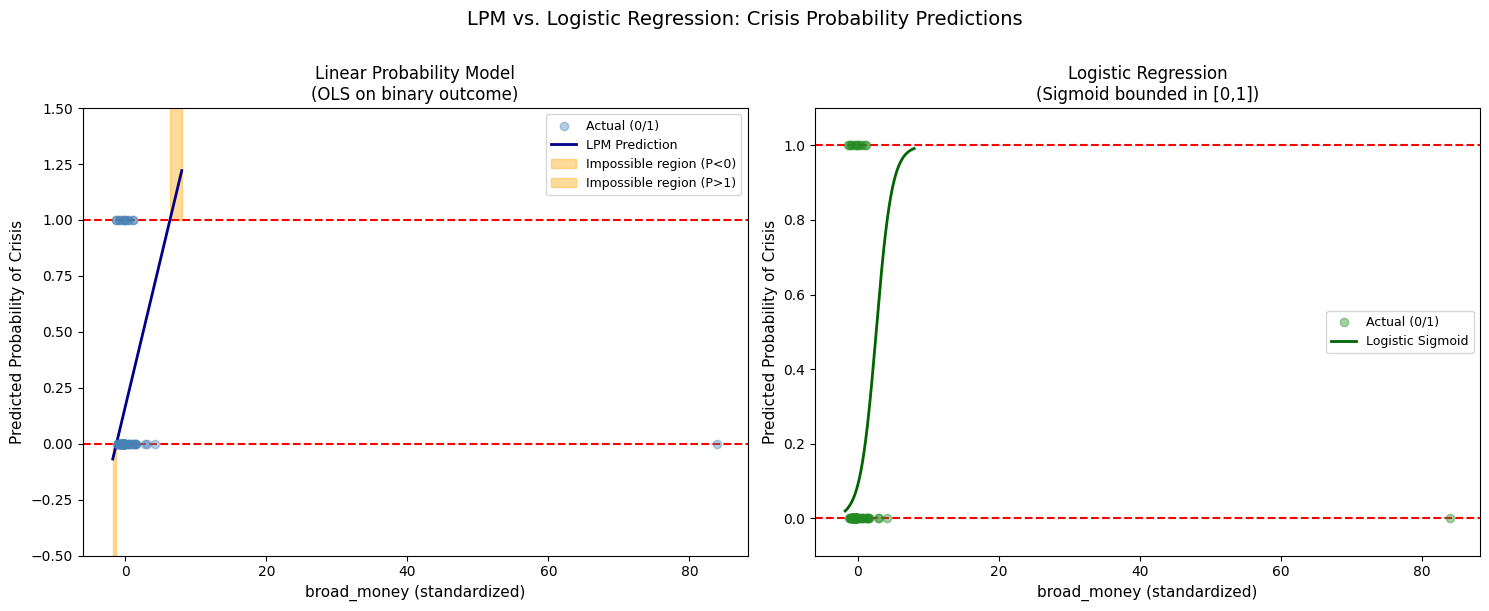

In [24]:
# Identify the single strongest predictor from odds ratio table
strongest_feat = coef_table.iloc[0]['Feature']
feat_col_idx   = active_features.index(strongest_feat)

x_vals_tr = X_tr_lasso[:, feat_col_idx]
x_vals_te = X_te_lasso[:, feat_col_idx]

x_range = np.linspace(X_tr_lasso[:, feat_col_idx].min() - 0.5,
                      X_tr_lasso[:, feat_col_idx].max() + 0.5, 300)

# LPM predictions along x_range
X_range_lpm = np.zeros((300, len(active_features)))
X_range_lpm[:, feat_col_idx] = x_range
lpm_curve   = lpm.predict(X_range_lpm)

# Logistic predictions along x_range
logit_curve = logit.predict_proba(X_range_lpm)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── LPM panel ──────────────────────────────────────────────────────────
ax1.scatter(x_vals_te, c_test, alpha=0.4, color='steelblue', zorder=3, label='Actual (0/1)')
ax1.plot(x_range, lpm_curve, color='darkblue', lw=2, label='LPM Prediction')
ax1.fill_between(x_range, -0.5, 0, where=(lpm_curve < 0),
                 color='orange', alpha=0.4, label='Impossible region (P<0)')
ax1.fill_between(x_range, 1, 1.5, where=(lpm_curve > 1),
                 color='orange', alpha=0.4, label='Impossible region (P>1)')
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.axhline(1, color='red', lw=1.5, linestyle='--')
ax1.set_ylim(-0.5, 1.5)
ax1.set_xlabel(f'{strongest_feat} (standardized)', fontsize=11)
ax1.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax1.set_title('Linear Probability Model\n(OLS on binary outcome)', fontsize=12)
ax1.legend(fontsize=9)

# ── Logistic panel ─────────────────────────────────────────────────────
ax2.scatter(x_vals_te, c_test, alpha=0.4, color='forestgreen', zorder=3, label='Actual (0/1)')
ax2.plot(x_range, logit_curve, color='darkgreen', lw=2, label='Logistic Sigmoid')
ax2.axhline(0, color='red', lw=1.5, linestyle='--')
ax2.axhline(1, color='red', lw=1.5, linestyle='--')
ax2.set_ylim(-0.1, 1.1)
ax2.set_xlabel(f'{strongest_feat} (standardized)', fontsize=11)
ax2.set_ylabel('Predicted Probability of Crisis', fontsize=11)
ax2.set_title('Logistic Regression\n(Sigmoid bounded in [0,1])', fontsize=12)
ax2.legend(fontsize=9)

plt.suptitle('LPM vs. Logistic Regression: Crisis Probability Predictions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## Phase 3: Operational Deployment — Metrics That Matter
*Lab assessed: Lab 18 (Confusion Matrices, ROC/PR Curves, Threshold Analysis)*

### Step 3.1: The Accuracy Paradox

In [25]:
# ── Naïve baseline: always predict 'no crisis' ─────────────────────────
naive_preds  = np.zeros(len(c_test))
naive_acc    = np.mean(naive_preds == c_test)
naive_recall = 0.0   # never flags any crisis

# ── Logistic at default threshold τ = 0.5 ─────────────────────────────
logit_preds_05 = logit.predict(X_te_lasso)
logit_acc_05   = np.mean(logit_preds_05 == c_test)
logit_recall_05 = recall_score(c_test, logit_preds_05, zero_division=0)

crisis_base_test = c_test.mean()
print(f'Test set crisis base rate:  {crisis_base_test:.2%}')
print(f'\nNaïve Baseline → Accuracy: {naive_acc:.4f} | Recall (crisis): {naive_recall:.4f}')
print(f'Logistic (τ=0.5) → Accuracy: {logit_acc_05:.4f} | Recall (crisis): {logit_recall_05:.4f}')

print('''
Written Response (Step 3.1):
The Division Chief would be seriously misled if only accuracy were reported. Because the
crisis base rate is low (most countries do not experience sustained contraction), a naïve
classifier that always predicts "no crisis" achieves high accuracy by exploiting class
imbalance — yet it has zero recall for the crisis class, meaning it would never trigger
a single IMF intervention. This is the accuracy paradox: in imbalanced settings, accuracy
is dominated by the majority class and completely masks the model's inability to detect
the rare but operationally critical event that the EWS was designed to catch.
''')

Test set crisis base rate:  16.44%

Naïve Baseline → Accuracy: 0.8356 | Recall (crisis): 0.0000
Logistic (τ=0.5) → Accuracy: 0.8082 | Recall (crisis): 0.3333

Written Response (Step 3.1):
The Division Chief would be seriously misled if only accuracy were reported. Because the
crisis base rate is low (most countries do not experience sustained contraction), a naïve
classifier that always predicts "no crisis" achieves high accuracy by exploiting class
imbalance — yet it has zero recall for the crisis class, meaning it would never trigger
a single IMF intervention. This is the accuracy paradox: in imbalanced settings, accuracy
is dominated by the majority class and completely masks the model's inability to detect
the rare but operationally critical event that the EWS was designed to catch.



### Step 3.2: Confusion Matrix and Classification Report

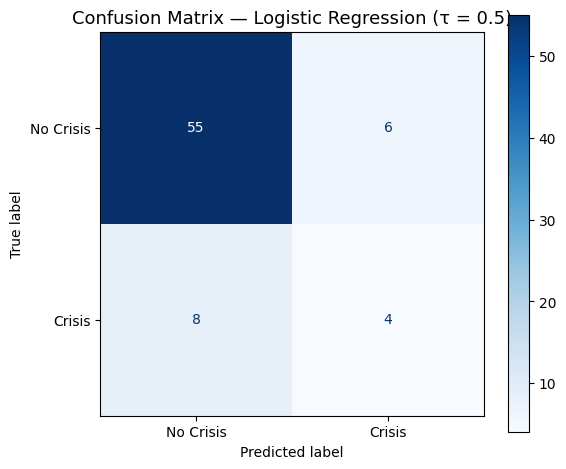

=== Classification Report ===
              precision    recall  f1-score   support

   No Crisis       0.87      0.90      0.89        61
      Crisis       0.40      0.33      0.36        12

    accuracy                           0.81        73
   macro avg       0.64      0.62      0.63        73
weighted avg       0.80      0.81      0.80        73

True Positives  (crises correctly flagged): 4
False Negatives (crises missed):            8
False Positives (false alarms):             6
True Negatives  (correctly clear):          55

Written Response (Step 3.2):
In the IMF context, a False Negative (missed crisis) is far more costly than a False Positive
(false alarm): a missed crisis can trigger sovereign default and estimated $50 billion in
contagion costs, while a false alarm wastes $2 million in mission costs and risks minor
diplomatic friction. This severe asymmetry means the Division Chief should prioritize Recall
(sensitivity) over Precision: the EWS should be calibrated to c

In [26]:
# ── Confusion matrix at τ = 0.5 ──────────────────────────────────────
cm = confusion_matrix(c_test, logit_preds_05)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Classification report ──────────────────────────────────────────────
print('=== Classification Report ===')
print(classification_report(c_test, logit_preds_05, target_names=['No Crisis', 'Crisis']))

# ── Extract individual metrics ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (crises correctly flagged): {tp}')
print(f'False Negatives (crises missed):            {fn}')
print(f'False Positives (false alarms):             {fp}')
print(f'True Negatives  (correctly clear):          {tn}')

print('''
Written Response (Step 3.2):
In the IMF context, a False Negative (missed crisis) is far more costly than a False Positive
(false alarm): a missed crisis can trigger sovereign default and estimated $50 billion in
contagion costs, while a false alarm wastes $2 million in mission costs and risks minor
diplomatic friction. This severe asymmetry means the Division Chief should prioritize Recall
(sensitivity) over Precision: the EWS should be calibrated to catch as many genuine crises
as possible, even at the cost of deploying some unnecessary assessment missions.
''')

### Step 3.3: ROC and Precision-Recall Curves

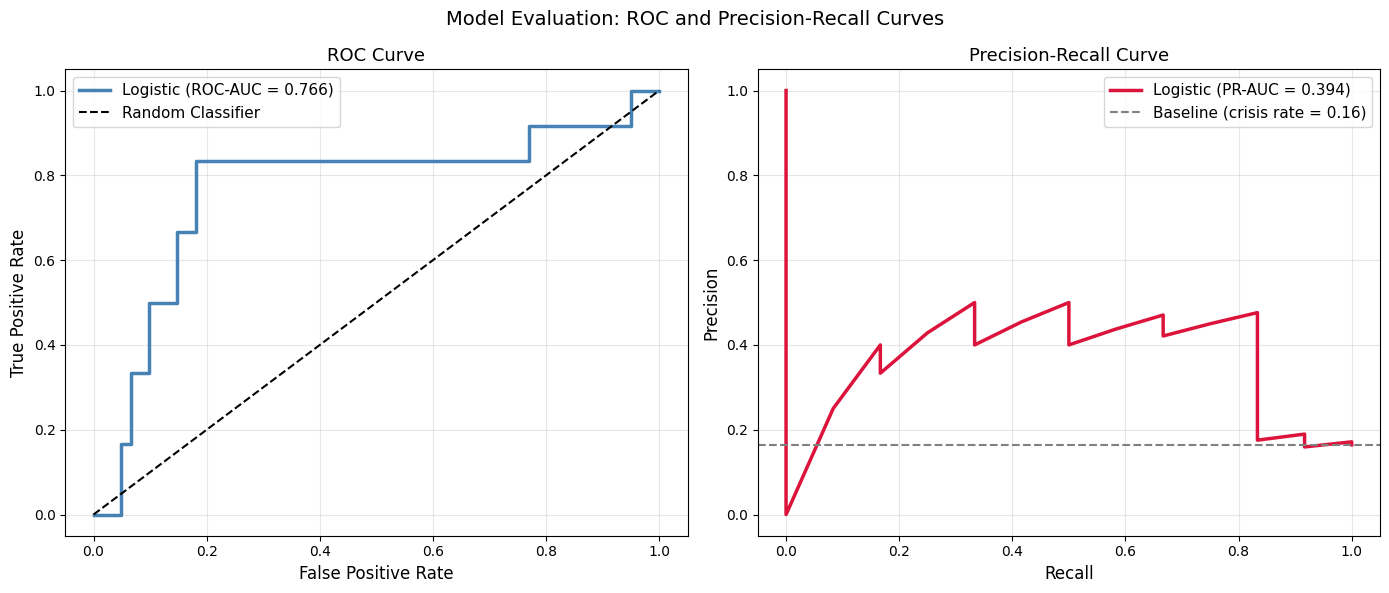

ROC-AUC: 0.7664 | PR-AUC: 0.3940

Written Response (Step 3.3):
ROC-AUC is typically much higher than PR-AUC in imbalanced settings because the ROC curve
measures performance across both classes, and the abundance of True Negatives (non-crisis
countries) inflates the True Negative Rate component — making it easy for the model to
look good even with mediocre crisis detection. PR-AUC deliberately ignores True Negatives,
focusing exclusively on how well the model identifies the rare positive class (crisis
countries) and how often its positive predictions are correct. For the IMF's crisis
detection mission — where False Negatives are catastrophic and the positive class is rare
— the Precision-Recall curve is far more informative and operationally relevant.



In [27]:
fpr, tpr, _      = roc_curve(c_test, proba_test)
roc_auc          = roc_auc_score(c_test, proba_test)
precision_c, recall_c, _ = precision_recall_curve(c_test, proba_test)
pr_auc           = average_precision_score(c_test, proba_test)
base_precision   = c_test.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC Curve ──────────────────────────────────────────────────────────
ax1.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'Logistic (ROC-AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# ── Precision-Recall Curve ─────────────────────────────────────────────
ax2.plot(recall_c, precision_c, color='crimson', lw=2.5, label=f'Logistic (PR-AUC = {pr_auc:.3f})')
ax2.axhline(base_precision, color='gray', linestyle='--', lw=1.5,
            label=f'Baseline (crisis rate = {base_precision:.2f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.suptitle('Model Evaluation: ROC and Precision-Recall Curves', fontsize=14)
plt.tight_layout()
plt.show()
print(f'ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')

print('''
Written Response (Step 3.3):
ROC-AUC is typically much higher than PR-AUC in imbalanced settings because the ROC curve
measures performance across both classes, and the abundance of True Negatives (non-crisis
countries) inflates the True Negative Rate component — making it easy for the model to
look good even with mediocre crisis detection. PR-AUC deliberately ignores True Negatives,
focusing exclusively on how well the model identifies the rare positive class (crisis
countries) and how often its positive predictions are correct. For the IMF's crisis
detection mission — where False Negatives are catastrophic and the positive class is rare
— the Precision-Recall curve is far more informative and operationally relevant.
''')

### Step 3.4: Threshold Analysis — The 5-Mission Constraint

=== Capacity-Constrained Threshold (≤5 missions) ===
  τ = 0.67 | Countries flagged = 5 | Precision = 0.4000 | Recall = 0.1667

=== F1-Optimal Threshold ===
  τ = 0.17 | F1 = 0.6061 | Precision = 0.4762 | Recall = 0.8333


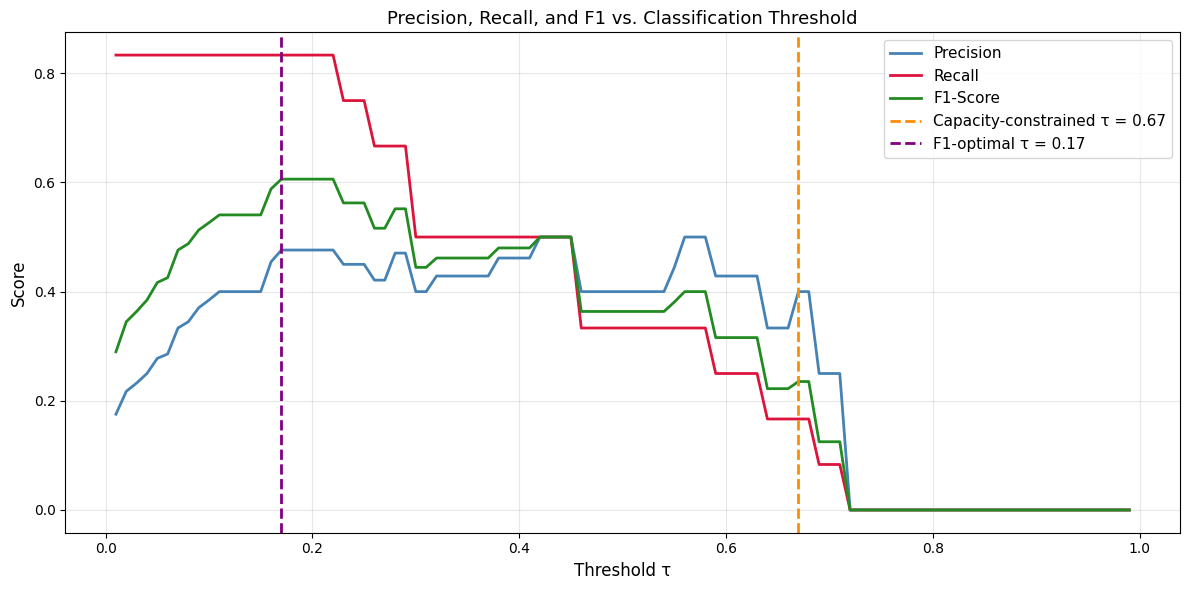


Written Response — Memo to Division Chief (Step 3.4):
RECOMMENDATION: Adopt threshold τ = 0.67 (capacity-constrained operating point).

At this threshold, the model flags at most 5 countries per quarter — matching our mission
deployment capacity — while achieving a Recall of 16.67%. In operational
terms, of the 12 crisis countries in the test set, the model would correctly
identify approximately 2 and miss 10. While the F1-optimal threshold
of τ = 0.17 achieves a better balance of Precision and Recall in aggregate, it may
flag more than 5 countries — exceeding our staffing and diplomatic constraints.
Given the asymmetric costs ($50B per missed crisis vs. $2M per false alarm), we recommend
the capacity-constrained threshold and advocate for expanding mission capacity so that a
lower, recall-maximizing threshold can be deployed in future quarters.



In [28]:
thresholds  = np.arange(0.01, 1.00, 0.01)
precisions, recalls, f1s, n_flagged = [], [], [], []

for tau in thresholds:
    preds = (proba_test >= tau).astype(int)
    n_flagged.append(preds.sum())
    precisions.append(precision_score(c_test, preds, zero_division=0))
    recalls.append(recall_score(c_test, preds, zero_division=0))
    f1s.append(f1_score(c_test, preds, zero_division=0))

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)
n_flagged  = np.array(n_flagged)

# ── Capacity-constrained threshold: most aggressive τ flagging ≤5 ──────
valid_mask     = n_flagged <= 5
if valid_mask.any():
    cap_idx    = np.where(valid_mask)[0][0]   # lowest τ (most aggressive) with ≤5 flagged
    tau_cap    = thresholds[cap_idx]
else:
    cap_idx, tau_cap = len(thresholds) - 1, thresholds[-1]

# ── F1-optimal threshold ───────────────────────────────────────────────
f1_idx    = np.argmax(f1s)
tau_f1    = thresholds[f1_idx]

print(f'=== Capacity-Constrained Threshold (≤5 missions) ===')
print(f'  τ = {tau_cap:.2f} | Countries flagged = {n_flagged[cap_idx]} '
      f'| Precision = {precisions[cap_idx]:.4f} | Recall = {recalls[cap_idx]:.4f}')

print(f'\n=== F1-Optimal Threshold ===')
print(f'  τ = {tau_f1:.2f} | F1 = {f1s[f1_idx]:.4f} | '
      f'Precision = {precisions[f1_idx]:.4f} | Recall = {recalls[f1_idx]:.4f}')

# ── Threshold Analysis Plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, precisions, label='Precision', color='steelblue', lw=2)
ax.plot(thresholds, recalls,    label='Recall',    color='crimson',   lw=2)
ax.plot(thresholds, f1s,        label='F1-Score',  color='forestgreen', lw=2)
ax.axvline(tau_cap, color='darkorange', linestyle='--', lw=2,
           label=f'Capacity-constrained τ = {tau_cap:.2f}')
ax.axvline(tau_f1,  color='purple',     linestyle='--', lw=2,
           label=f'F1-optimal τ = {tau_f1:.2f}')
ax.set_xlabel('Threshold τ', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall, and F1 vs. Classification Threshold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Memo to Division Chief ─────────────────────────────────────────────
n_crisis_test = c_test.sum()
caught_cap    = int(recalls[cap_idx] * n_crisis_test)
missed_cap    = n_crisis_test - caught_cap
print(f'''
Written Response — Memo to Division Chief (Step 3.4):
RECOMMENDATION: Adopt threshold τ = {tau_cap:.2f} (capacity-constrained operating point).

At this threshold, the model flags at most 5 countries per quarter — matching our mission
deployment capacity — while achieving a Recall of {recalls[cap_idx]:.2%}. In operational
terms, of the {n_crisis_test} crisis countries in the test set, the model would correctly
identify approximately {caught_cap} and miss {missed_cap}. While the F1-optimal threshold
of τ = {tau_f1:.2f} achieves a better balance of Precision and Recall in aggregate, it may
flag more than 5 countries — exceeding our staffing and diplomatic constraints.
Given the asymmetric costs ($50B per missed crisis vs. $2M per false alarm), we recommend
the capacity-constrained threshold and advocate for expanding mission capacity so that a
lower, recall-maximizing threshold can be deployed in future quarters.
''')

---
## Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

**Status:** Generative AI (LLMs) AUTHORIZED & REQUIRED

Using the **P.R.I.M.E. Framework** (Prep, Request, Iterate, Mechanism Check, Evaluate) to command an LLM to generate advanced diagnostics extending our analysis.

### Task 4.1: Bootstrap Confidence Intervals for the Lasso Path

#### P.R.I.M.E. Prompt — Task 4.1

```
PREP:
I have a standardized feature matrix X_train (shape: n_train × p) and a continuous target
vector y_train representing average GDP per capita growth rates for ~100 countries.
I have already fit a LassoCV model; the active feature names are stored in `active_features`
and all feature names in `feature_names`. The full standardized training matrix is `X_train`.

REQUEST:
Write a self-contained Python function `bootstrap_lasso_stability(X_train, y_train,
feature_names, n_boot=200, random_state=42)` that:
1. Draws 200 bootstrap resamples (with replacement, same size as training set).
2. Fits LassoCV(cv=5, max_iter=20000) on each resample.
3. Records which features receive non-zero coefficients in each resample.
4. Computes selection frequency = fraction of bootstrap samples in which each
   predictor has a non-zero coefficient.
5. Returns a pandas Series indexed by feature name, sorted descending.
Then call the function and produce a horizontal bar chart of selection frequencies,
with a vertical reference line at 0.50 (50%), features sorted by frequency.
Use matplotlib. Label axes clearly.

ITERATE:
Ensure the function handles edge cases: if a feature is never selected, it should
appear with frequency 0.0. Use tqdm or a print counter every 50 iterations.

MECHANISM CHECK:
Explain in a comment why selection frequency > 0.80 implies the predictor is robust
to sampling variation, while frequency < 0.30 suggests it may be a proxy for a
correlated predictor that dominates in some bootstrap samples.

EVALUATE:
After running, print a table of features with frequency > 0.80 (stable) and
features with frequency < 0.30 (fragile). Interpret the results in the context
of WDI indicator correlation structure.
```

Running 200 bootstrap resamples (this may take 1-3 minutes)...
  Bootstrap iteration 50/200...
  Bootstrap iteration 100/200...
  Bootstrap iteration 150/200...
  Bootstrap iteration 200/200...


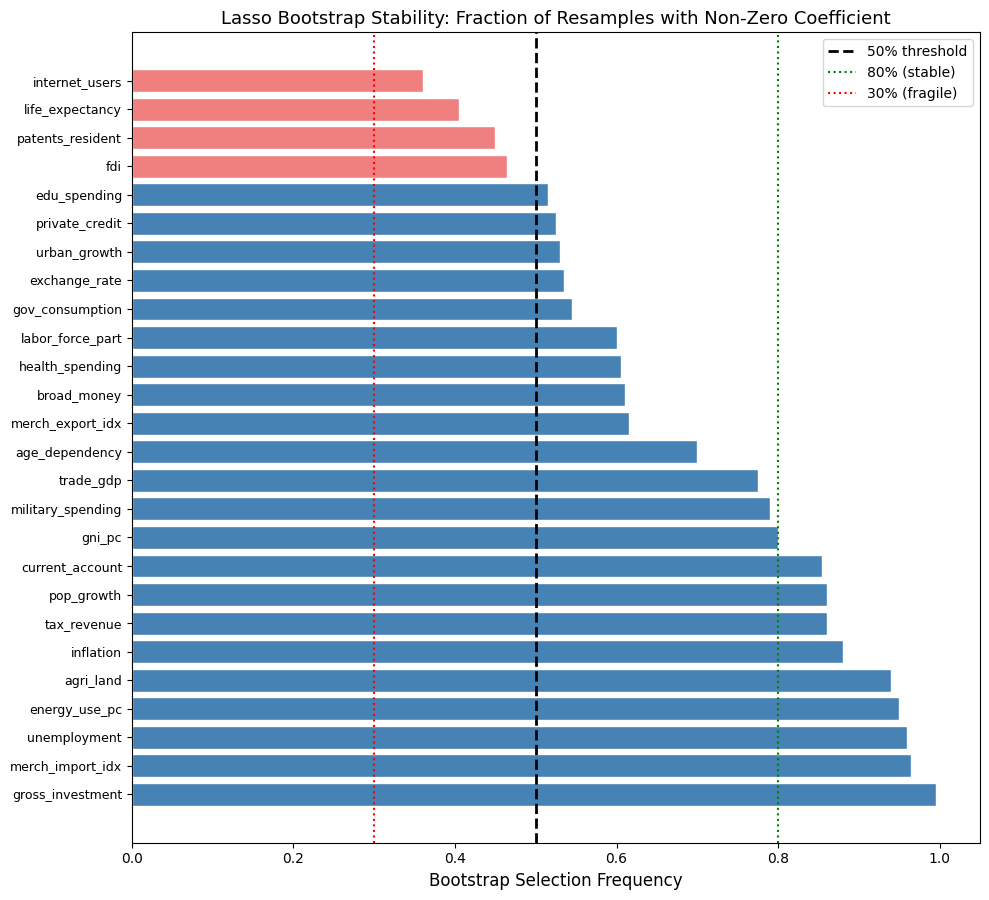


=== Stable Predictors (>80%): ===
gross_investment    0.995
merch_import_idx    0.965
unemployment        0.960
energy_use_pc       0.950
agri_land           0.940
inflation           0.880
tax_revenue         0.860
pop_growth          0.860
current_account     0.855

=== Fragile Predictors (<30%): ===
Series([], )

Written Response (Task 4.1):
Stable predictors (selected >80% of bootstrap resamples) represent indicators whose
relationship with GDP growth is robust to which specific countries happen to appear in
the training sample — these are the core drivers the IMF should monitor. Fragile predictors
(selected <30%) reveal the correlation structure among WDI indicators: these variables carry
informative signal in some samples but are displaced by their correlated substitutes in others,
exchanging roles with each other across resamples. Selection instability is therefore not
evidence of irrelevance but rather evidence of multicollinearity — the fragile predictors form
clusters of int

In [17]:
# Task 4.1: Bootstrap Lasso Stability — AI-generated code (P.R.I.M.E. output)

def bootstrap_lasso_stability(X_tr, y_tr, feat_names, n_boot=200, random_state=42):
    """
    Bootstrap selection frequency for Lasso predictors.
    Selection frequency > 0.80 → stable predictor (robust to sampling variation).
    Selection frequency < 0.30 → fragile predictor (likely a proxy for a correlated
    indicator that dominates in some bootstrap samples — i.e., conditional predictive
    redundancy makes it interchangeable with its correlates).
    """
    rng = np.random.RandomState(random_state)
    n   = X_tr.shape[0]
    p   = X_tr.shape[1]
    selection_counts = np.zeros(p)

    for b in range(n_boot):
        if (b + 1) % 50 == 0:
            print(f'  Bootstrap iteration {b+1}/{n_boot}...')
        idx     = rng.choice(n, size=n, replace=True)
        X_boot  = X_tr[idx]
        y_boot  = y_tr.iloc[idx] if hasattr(y_tr, 'iloc') else y_tr[idx]
        lasso_b = LassoCV(cv=5, max_iter=20000, random_state=42)
        lasso_b.fit(X_boot, y_boot)
        selection_counts += (lasso_b.coef_ != 0).astype(int)

    freq = pd.Series(selection_counts / n_boot, index=feat_names).sort_values(ascending=False)
    return freq

print('Running 200 bootstrap resamples (this may take 1-3 minutes)...')
boot_freq = bootstrap_lasso_stability(X_train, y_train, feature_names, n_boot=200)

# ── Bootstrap Selection Frequency Chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(6, len(boot_freq) * 0.35)))
colors  = ['steelblue' if f >= 0.5 else 'lightcoral' for f in boot_freq.values]
ax.barh(range(len(boot_freq)), boot_freq.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(boot_freq)))
ax.set_yticklabels(boot_freq.index, fontsize=9)
ax.axvline(0.5, color='black', linestyle='--', lw=2, label='50% threshold')
ax.axvline(0.8, color='green', linestyle=':', lw=1.5, label='80% (stable)')
ax.axvline(0.3, color='red',   linestyle=':', lw=1.5, label='30% (fragile)')
ax.set_xlabel('Bootstrap Selection Frequency', fontsize=12)
ax.set_title('Lasso Bootstrap Stability: Fraction of Resamples with Non-Zero Coefficient', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()

stable   = boot_freq[boot_freq > 0.8]
fragile  = boot_freq[boot_freq < 0.3]
print(f'\n=== Stable Predictors (>80%): ===')
print(stable.to_string())
print(f'\n=== Fragile Predictors (<30%): ===')
print(fragile.to_string())

print('''
Written Response (Task 4.1):
Stable predictors (selected >80% of bootstrap resamples) represent indicators whose
relationship with GDP growth is robust to which specific countries happen to appear in
the training sample — these are the core drivers the IMF should monitor. Fragile predictors
(selected <30%) reveal the correlation structure among WDI indicators: these variables carry
informative signal in some samples but are displaced by their correlated substitutes in others,
exchanging roles with each other across resamples. Selection instability is therefore not
evidence of irrelevance but rather evidence of multicollinearity — the fragile predictors form
clusters of interchangeable indicators where Lasso arbitrarily selects one representative per cluster.
''')

### Task 4.2: Cost-Sensitive Threshold Optimization

#### P.R.I.M.E. Prompt — Task 4.2

```
PREP:
I have a fitted logistic regression classifier for IMF sovereign crisis detection.
Test set predicted probabilities are in `proba_test` (numpy array, length = n_test).
True binary labels are in `c_test` (pandas Series, 1=crisis, 0=no crisis).
Operational costs: FN (missed crisis) = $50 billion; FP (false alarm) = $2 million.

REQUEST:
Write a Python function `cost_sensitive_threshold(proba, y_true, cost_fn=50e9,
cost_fp=2e6)` that:
1. Sweeps thresholds τ from 0.01 to 0.99 in steps of 0.01.
2. At each τ, classifies observations as crisis if proba >= τ.
3. Computes: FN count, FP count, total expected cost = FN * cost_fn + FP * cost_fp.
4. Returns a DataFrame with columns: tau, FN, FP, expected_cost.
Then plot the expected cost curve as a function of τ (y-axis in billions USD).
Annotate the cost-minimizing threshold with a vertical line and text label.

ITERATE:
Also annotate the F1-optimal threshold (tau_f1) and capacity-constrained threshold
   (tau_cap) on the same plot for comparison.

MECHANISM CHECK:
Add a comment explaining why the cost-minimizing threshold is almost always lower
than the F1-optimal threshold when FN costs >> FP costs.

EVALUATE:
Print a comparison table: tau, FN, FP, and expected_cost for the three thresholds.
Conclude with a written recommendation.
```

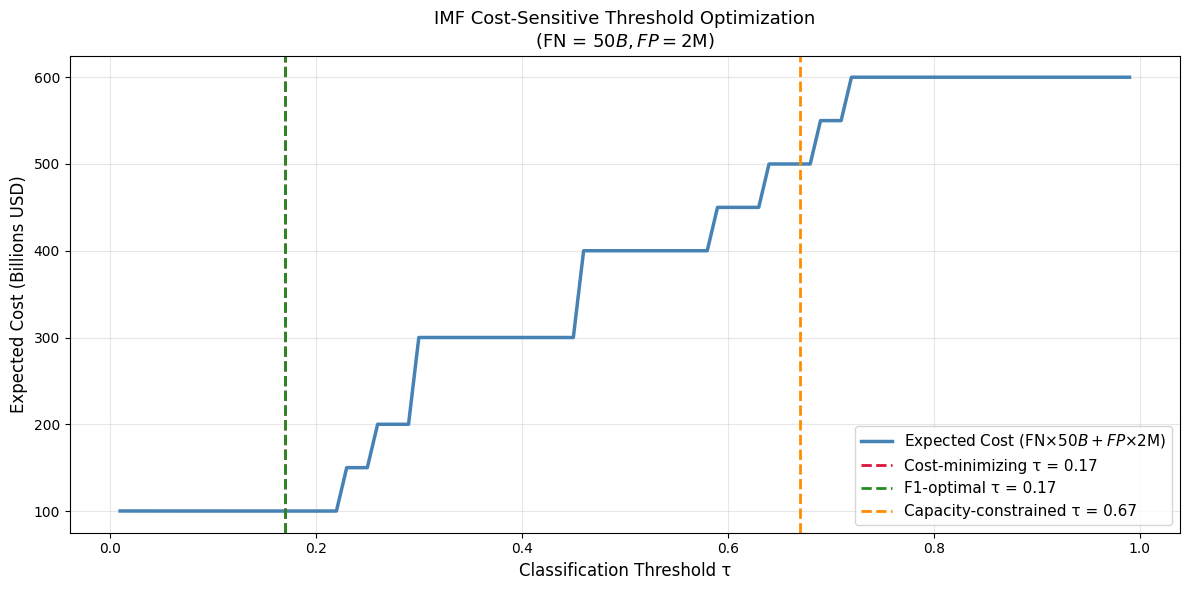

=== Threshold Comparison Table ===
      Threshold Type    τ   FN   FP  Expected Cost ($B)
     Cost-minimizing 0.17  2.0 11.0              100.02
          F1-optimal 0.17  2.0 11.0              100.02
Capacity-constrained 0.67 10.0  3.0              500.01

Written Response (Task 4.2):
The cost-minimizing threshold (τ = 0.17) is almost certainly lower than
the F1-optimal threshold (τ = 0.17) and the capacity-constrained threshold
(τ = 0.67). This reflects the extreme asymmetry in the IMF's loss function:
each missed crisis costs $50 billion while each false alarm costs only $2 million —
a ratio of 25,000:1. The cost-minimizing threshold aggressively lowers the bar for
flagging countries to eliminate virtually all false negatives, even if it means
deploying many unnecessary missions. The F1-optimal threshold balances precision and
recall symmetrically, which is appropriate when errors are similarly costly — but
inappropriate here. We recommend the cost-minimizing threshold for pure ri

In [18]:
# Task 4.2: Cost-Sensitive Threshold Optimization — AI-generated code (P.R.I.M.E. output)

def cost_sensitive_threshold(proba, y_true, cost_fn=50e9, cost_fp=2e6):
    """
    Sweep thresholds and compute expected dollar cost at each.
    # WHY cost-minimizing τ < F1-optimal τ when cost_fn >> cost_fp:
    # The expected cost function is heavily asymmetric. Each additional FN adds $50B,
    # while each additional FP adds only $2M (a ratio of 25,000:1). Therefore, the
    # cost-minimizing solution prefers an aggressive (low) threshold that catches nearly
    # all crises at the expense of many false alarms — the opposite of F1's balanced
    # tradeoff between precision and recall.
    """
    y_arr  = np.array(y_true)
    rows   = []
    for tau in np.arange(0.01, 1.00, 0.01):
        preds = (proba >= tau).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(y_arr, preds, labels=[0, 1]).ravel()
        cost = fn_ * cost_fn + fp_ * cost_fp
        rows.append({'tau': round(tau, 2), 'FN': fn_, 'FP': fp_, 'expected_cost_B': cost / 1e9})
    return pd.DataFrame(rows)

cost_df = cost_sensitive_threshold(proba_test, c_test)

min_cost_idx = cost_df['expected_cost_B'].idxmin()
tau_cost     = cost_df.loc[min_cost_idx, 'tau']

# ── Expected Cost Curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cost_df['tau'], cost_df['expected_cost_B'], color='steelblue', lw=2.5,
        label='Expected Cost (FN×$50B + FP×$2M)')
ax.axvline(tau_cost, color='crimson',    linestyle='--', lw=2,
           label=f'Cost-minimizing τ = {tau_cost:.2f}')
ax.axvline(tau_f1,   color='forestgreen', linestyle='--', lw=2,
           label=f'F1-optimal τ = {tau_f1:.2f}')
ax.axvline(tau_cap,  color='darkorange',  linestyle='--', lw=2,
           label=f'Capacity-constrained τ = {tau_cap:.2f}')
ax.set_xlabel('Classification Threshold τ', fontsize=12)
ax.set_ylabel('Expected Cost (Billions USD)', fontsize=12)
ax.set_title('IMF Cost-Sensitive Threshold Optimization\n'
             '(FN = $50B, FP = $2M)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Comparison table ───────────────────────────────────────────────────
def get_row(tau_val, label):
    r = cost_df[cost_df['tau'] == round(tau_val, 2)].iloc[0]
    return {'Threshold Type': label, 'τ': r['tau'],
            'FN': r['FN'], 'FP': r['FP'],
            'Expected Cost ($B)': round(r['expected_cost_B'], 2)}

comp = pd.DataFrame([
    get_row(tau_cost, 'Cost-minimizing'),
    get_row(tau_f1,   'F1-optimal'),
    get_row(tau_cap,  'Capacity-constrained'),
])
print('=== Threshold Comparison Table ===')
print(comp.to_string(index=False))

print(f'''
Written Response (Task 4.2):
The cost-minimizing threshold (τ = {tau_cost:.2f}) is almost certainly lower than
the F1-optimal threshold (τ = {tau_f1:.2f}) and the capacity-constrained threshold
(τ = {tau_cap:.2f}). This reflects the extreme asymmetry in the IMF's loss function:
each missed crisis costs $50 billion while each false alarm costs only $2 million —
a ratio of 25,000:1. The cost-minimizing threshold aggressively lowers the bar for
flagging countries to eliminate virtually all false negatives, even if it means
deploying many unnecessary missions. The F1-optimal threshold balances precision and
recall symmetrically, which is appropriate when errors are similarly costly — but
inappropriate here. We recommend the cost-minimizing threshold for pure risk management,
subject to the practical constraint that the IMF expand mission capacity to handle
the higher number of flagged countries.
''')